In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
import joblib

In [2]:
df = yf.download("SPY", period="3mo")

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


In [3]:
# Compute RSI
def compute_rsi(series, period=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

In [8]:
# Candlestick Features
def generate_candlestick_features(df):
    df = df.copy()
    df['Body'] = (df['Close'] - df['Open']).abs()
    import numpy as np

    df['UT'] = df['High'] - np.maximum(df['Open'], df['Close'])
    df['LT'] = np.minimum(df['Open'], df['Close']) - df['Low']
    df['Range'] = df['High'] - df['Low']
    df['Body_pct'] = df['Body'] / df['Range']
    df['UT_pct'] = df['UT'] / df['Range']
    df['LT_pct'] = df['LT'] / df['Range']
    for col in ['Body','UT','LT']:
        df[f'{col}_MA'] = df[col].rolling(20).mean()
    df['AllowTrade'] = (
        (df['Body'] > df['Body_MA']) |
        (df['UT'] > df['UT_MA']) |
        (df['LT'] > df['LT_MA'])
    ).astype(int)
    return df

In [5]:
# Momentum Indicators
def add_momentum_indicators(df):
    df['MA5'] = df['Close'].rolling(5).mean()
    df['MA20'] = df['Close'].rolling(20).mean()
    df['Momentum_5'] = df['Close'] - df['Close'].shift(5)
    df['RSI_14'] = compute_rsi(df['Close'], 14)
    return df

In [6]:
# Simulated Trade Signal Labeling (for demonstration)
def label_trades(df):
    df = df.copy()
    df['signal'] = np.where(df['Momentum_5'] > 0.5, 'Buy',
                    np.where(df['Momentum_5'] < -0.5, 'Sell', 'Hold'))
    return df

In [9]:
df = generate_candlestick_features(df)

In [10]:
df = add_momentum_indicators(df)

In [11]:
df = label_trades(df)

In [12]:
df = df.dropna()

In [13]:
df

Price,Close,High,Low,Open,Volume,Body,UT,LT,Range,Body_pct,...,LT_pct,Body_MA,UT_MA,LT_MA,AllowTrade,MA5,MA20,Momentum_5,RSI_14,signal
Ticker,SPY,SPY,SPY,SPY,SPY,,,,,,...,,,,,,,,,,
Date,,,,,,,,,,,,,,,,,,,,,
2025-06-04,594.173462,596.187527,593.734756,595.200455,57314200,1.026993,0.987072,0.438706,2.452771,0.418707,...,0.178861,2.720969,1.511523,2.299705,0,591.086597,583.696442,8.175842,58.552021,Buy
2025-06-05,591.301941,597.234415,589.307836,595.868458,92278700,4.566517,1.365957,1.994105,7.926579,0.576102,...,0.251572,2.899442,1.446715,2.194513,1,591.684827,585.286740,2.991150,52.655282,Buy
2025-06-06,597.374023,599.059045,595.100715,596.895397,66588700,0.478627,1.685021,1.794682,3.958330,0.120916,...,0.453394,2.914401,1.278213,2.116743,1,593.629077,586.985718,9.721252,54.831784,Buy
2025-06-09,597.912415,599.477794,596.725920,597.952275,53016400,0.039860,1.525519,1.186495,2.751875,0.014485,...,0.431159,2.809711,1.303638,2.097300,1,595.018970,588.747510,6.949463,54.734378,Buy
2025-06-10,601.302368,601.691172,597.324139,598.450752,66247000,2.851616,0.388804,1.126613,4.367033,0.652987,...,0.257981,2.876515,1.322579,1.932784,0,596.412842,589.749048,6.969360,59.759530,Buy
2025-06-11,599.587463,603.276570,597.503658,602.409139,73658200,2.821676,0.867431,2.083806,5.772912,0.488779,...,0.360963,2.846602,1.254282,2.008561,1,597.495642,590.472906,5.414001,70.955994,Buy
2025-06-12,601.970398,601.970398,597.752886,598.241432,64129000,3.728966,0.000000,0.488546,4.217512,0.884163,...,0.115837,3.022084,1.195955,1.930788,1,599.629333,591.278522,10.668457,72.310916,Buy
2025-06-13,595.240295,600.075975,593.724756,596.735874,89506000,1.495579,3.340101,1.515539,6.351219,0.235479,...,0.238622,2.852584,1.337538,1.983632,1,599.202588,591.604556,-2.133728,68.229054,Sell


In [14]:
# Filter by AllowTrade (optional)
df = df[df['AllowTrade'] == 1]

In [15]:
features = ['Body_pct', 'UT_pct', 'LT_pct', 'Momentum_5', 'MA5', 'MA20', 'RSI_14']
X = df[features]
y = df['signal']

In [16]:
# Label Encoding
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [17]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

In [18]:
# Train Model
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=3,
    min_samples_split=5,
    class_weight="balanced",
    random_state=42
)

In [19]:
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=3, min_samples_split=5,
                       n_estimators=200, random_state=42)

In [20]:
# Evaluation
y_pred = model.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Classification Report:
              precision    recall  f1-score   support

         Buy       0.67      1.00      0.80         4
        Hold       0.00      0.00      0.00         2
        Sell       1.00      1.00      1.00         2

    accuracy                           0.75         8
   macro avg       0.56      0.67      0.60         8
weighted avg       0.58      0.75      0.65         8



/home/hiren/local/arh_venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/hiren/local/arh_venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/hiren/local/arh_venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [21]:
# Save Model & Encoder
joblib.dump(model, "rf_model.pkl")
joblib.dump(le, "rf_label_encoder.pkl")

['rf_label_encoder.pkl']

In [22]:
import joblib

model = joblib.load("rf_model.pkl")
label_encoder = joblib.load("rf_label_encoder.pkl")


In [23]:
import yfinance as yf
import pandas as pd
import numpy as np

# Download SPY data for prediction
df_new = yf.download("SPY", period="5d", interval="1d")  # or 1h, 15m, etc.

# Apply same feature engineering functions
df_new = generate_candlestick_features(df_new)
df_new = add_momentum_indicators(df_new)
df_new = df_new.dropna()  # Drop rows with NA (RSI etc.)

# Optional: use only rows flagged as AllowTrade
df_new = df_new[df_new['AllowTrade'] == 1]

# Match feature columns used in training
features = ['Body_pct', 'UT_pct', 'LT_pct', 'Momentum_5', 'MA5', 'MA20', 'RSI_14']
X_live = df_new[features]


[*********************100%***********************]  1 of 1 completed


In [24]:
# Predict encoded labels
y_pred_encoded = model.predict(X_live)

# Decode to original signal labels
signals = label_encoder.inverse_transform(y_pred_encoded)

# Attach signals to DataFrame
df_new['Predicted_Signal'] = signals

# View results
print(df_new[['Close', 'Predicted_Signal']].tail())


ValueError: Found array with 0 sample(s) (shape=(0, 7)) while a minimum of 1 is required by RandomForestClassifier.

In [25]:
# Check shape after feature engineering and filtering
print("X_live shape:", X_live.shape)

X_live shape: (0, 7)


In [26]:
if X_live.empty:
    print("No valid samples available for prediction.")
else:
    y_pred_encoded = model.predict(X_live)
    signals = label_encoder.inverse_transform(y_pred_encoded)
    df_new.loc[X_live.index, 'Predicted_Signal'] = signals
    print(df_new[['Close', 'Predicted_Signal']].tail())

No valid samples available for prediction.


In [39]:
import yfinance as yf
import pandas as pd
import numpy as np
import joblib

# --- Reuse feature engineering functions from training notebook ---
def compute_rsi(series, period=14):
    delta = series.diff()
    gain = delta.clip(lower=0).rolling(window=period).mean()
    loss = -delta.clip(upper=0).rolling(window=period).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

def generate_candlestick_features(df):
    df = df.copy()
    df['Body'] = (df['Close'] - df['Open']).abs()
    df['UT'] = df['High'] - np.maximum(df['Open'], df['Close'])
    df['LT'] = np.minimum(df['Open'], df['Close']) - df['Low']
    df['Range'] = df['High'] - df['Low']
    df['Body_pct'] = df['Body'] / df['Range']
    df['UT_pct'] = df['UT'] / df['Range']
    df['LT_pct'] = df['LT'] / df['Range']
    for col in ['Body','UT','LT']:
        df[f'{col}_MA'] = df[col].rolling(20).mean()
    df['AllowTrade'] = (
        (df['Body'] > df['Body_MA']) |
        (df['UT'] > df['UT_MA']) |
        (df['LT'] > df['LT_MA'])
    ).astype(int)
    return df

def add_momentum_indicators(df):
    df['MA5'] = df['Close'].rolling(5).mean()
    df['MA20'] = df['Close'].rolling(20).mean()
    df['Momentum_5'] = df['Close'] - df['Close'].shift(5)
    df['RSI_14'] = compute_rsi(df['Close'], 14)
    return df

# --- Load model and encoder ---
model = joblib.load("rf_model.pkl")
label_encoder = joblib.load("rf_label_encoder.pkl")

# --- Load new SPY data for signal prediction ---
df_new = yf.download("QQQ", period="9mo", interval="1wk")
df_new = generate_candlestick_features(df_new)
df_new = add_momentum_indicators(df_new)
df_new = df_new.dropna()

# Optional filter
df_new = df_new[df_new['AllowTrade'] == 1]

# Define features used in training
features = ['Body_pct', 'UT_pct', 'LT_pct', 'Momentum_5', 'MA5', 'MA20', 'RSI_14']

# Select features
X_live = df_new[features]

# --- Prediction only if valid rows exist ---
if X_live.empty:
    print("No valid samples available for prediction.")
else:
    y_pred_encoded = model.predict(X_live)
    signals = label_encoder.inverse_transform(y_pred_encoded)
    df_new.loc[X_live.index, 'Predicted_Signal'] = signals
    print("Predicted Signals:\n")
    print(df_new[['Close', 'Predicted_Signal']])


[*********************100%***********************]  1 of 1 completed

Predicted Signals:

Price            Close Predicted_Signal
Ticker             QQQ                 
Date                                   
2025-03-17  479.585388             Sell
2025-03-24  467.716461             Sell
2025-03-31  422.195862             Sell
2025-04-07  453.890228             Sell
2025-04-14  443.601807             Sell
2025-04-21  472.029877             Sell
2025-04-28  488.281616              Buy
2025-05-05  487.422577              Buy
2025-05-19  508.668701              Buy
2025-05-26  518.527649              Buy
2025-06-09  526.368896              Buy
2025-06-16  526.239014              Buy
2025-06-23  547.475159              Buy
2025-06-30  556.219971              Buy
2025-07-28  553.880005              Buy


In [40]:
print(df['signal'].value_counts())


signal
Buy     24
Sell    10
Hold     2
Name: count, dtype: int64


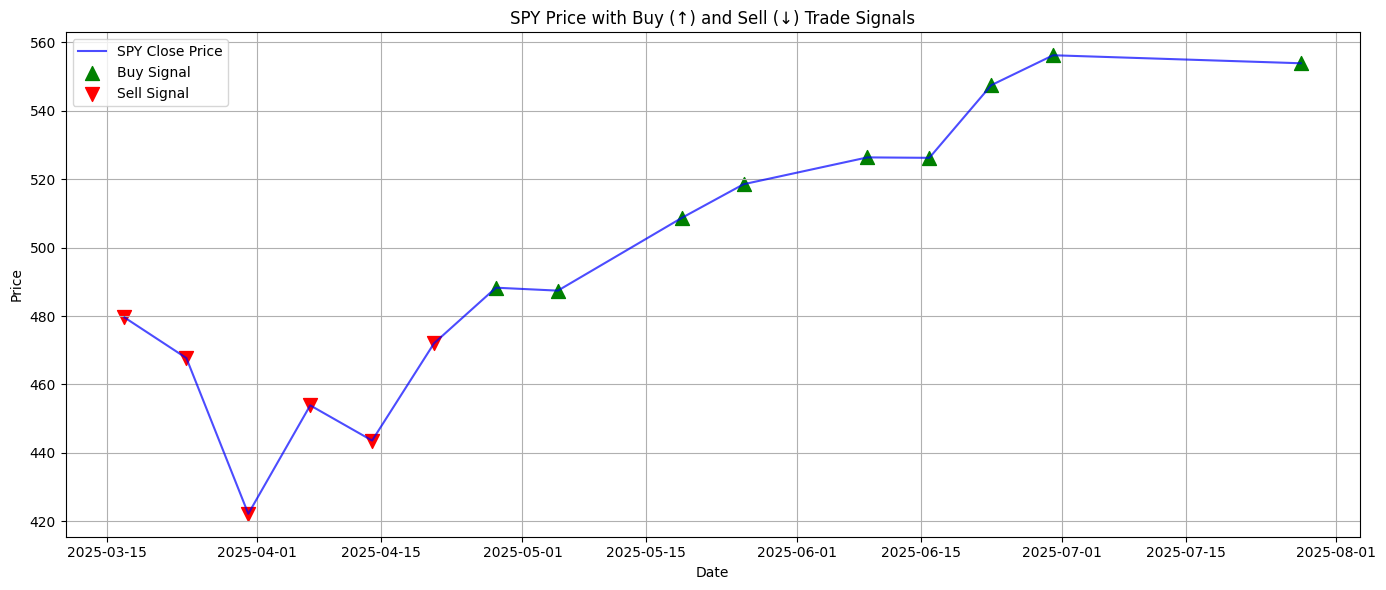

In [41]:
import matplotlib.pyplot as plt

# Filter signals
buy_signals = df_new[df_new['Predicted_Signal'] == 'Buy']
sell_signals = df_new[df_new['Predicted_Signal'] == 'Sell']

# Plot SPY Close Price
plt.figure(figsize=(14, 6))
plt.plot(df_new['Close'], label='SPY Close Price', color='blue', alpha=0.7)

# Plot Buy signals (green up arrows)
plt.scatter(buy_signals.index, buy_signals['Close'],
            marker='^', color='green', s=100, label='Buy Signal')

# Plot Sell signals (red down arrows)
plt.scatter(sell_signals.index, sell_signals['Close'],
            marker='v', color='red', s=100, label='Sell Signal')

# Format chart
plt.title("SPY Price with Buy (↑) and Sell (↓) Trade Signals")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



In [2]:
!pip show pandas


Name: pandas
Version: 2.2.3
Summary: Powerful data structures for data analysis, time series, and statistics
Home-page: https://pandas.pydata.org
Author: 
Author-email: The Pandas Development Team <pandas-dev@python.org>
License: BSD 3-Clause License

Copyright (c) 2008-2011, AQR Capital Management, LLC, Lambda Foundry, Inc. and PyData Development Team
All rights reserved.

Copyright (c) 2011-2023, Open source contributors.

Redistribution and use in source and binary forms, with or without
modification, are permitted provided that the following conditions are met:

* Redistributions of source code must retain the above copyright notice, this
  list of conditions and the following disclaimer.

* Redistributions in binary form must reproduce the above copyright notice,
  this list of conditions and the following disclaimer in the documentation
  and/or other materials provided with the distribution.

* Neither the name of the copyright holder nor the names of its
  contributors may be u